<a href="https://colab.research.google.com/github/rodrigorissettoterra/SENAI_Concepcao_e_Design_de_ML/blob/main/Convolutional_Neural_Networks_(CNNS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN / LeNet-5
Dataset MNIST

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

1. Carregar o dataset MNIST

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2. Normalizar os pixels para o intervalo [0, 1]

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

3. Adicionar o canal de cor

MNIST é escala de cinza, então o canal é 1

In [4]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Formato treino:", X_train.shape)
print("Formato teste:", X_test.shape)

Formato treino: (60000, 28, 28, 1)
Formato teste: (10000, 28, 28, 1)


## Modelo LeNet-5

4. Criar a arquitetura LeNet-5

In [5]:
model = models.Sequential([
    layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', padding='same', input_shape=(28, 28, 1)),
    layers.AveragePooling2D(pool_size=(2, 2)),

    layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compilar e treinar

5. Compilar o modelo

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

6. Treinar o modelo

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.9007 - loss: 0.3474 - val_accuracy: 0.9622 - val_loss: 0.1370
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.9607 - loss: 0.1315 - val_accuracy: 0.9743 - val_loss: 0.0847
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 74ms/step - accuracy: 0.9740 - loss: 0.0867 - val_accuracy: 0.9773 - val_loss: 0.0748
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9812 - loss: 0.0628 - val_accuracy: 0.9822 - val_loss: 0.0623
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.9847 - loss: 0.0504 - val_accuracy: 0.9840 - val_loss: 0.0561
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.9879 - loss: 0.0398 - val_accuracy: 0.9835 - val_loss: 0.0548
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.9899 - loss: 0.0324 - val_accuracy: 0.9868 - val_loss: 0.0476
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9918 - loss: 0.0270 - 

## Avaliar o modelo

7. Avaliar no conjunto de teste

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Loss no teste:", test_loss)
print("Acurácia no teste:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9849 - loss: 0.0473
Loss no teste: 0.047331929206848145
Acurácia no teste: 0.9848999977111816


## Fazer previsões

8. Testar algumas previsões

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


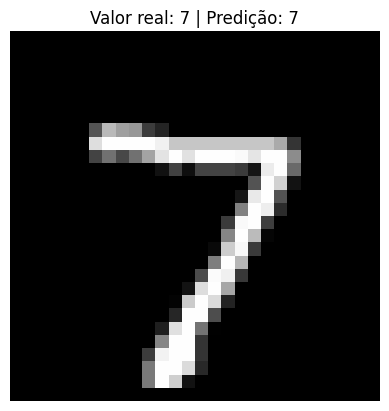

In [9]:
import numpy as np

predictions = model.predict(X_test)

index = 0

plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Valor real: {y_test[index]} | Predição: {np.argmax(predictions[index])}")
plt.axis("off")
plt.show()

## Gráfico de acurácia

9. Visualizar evolução da acurácia

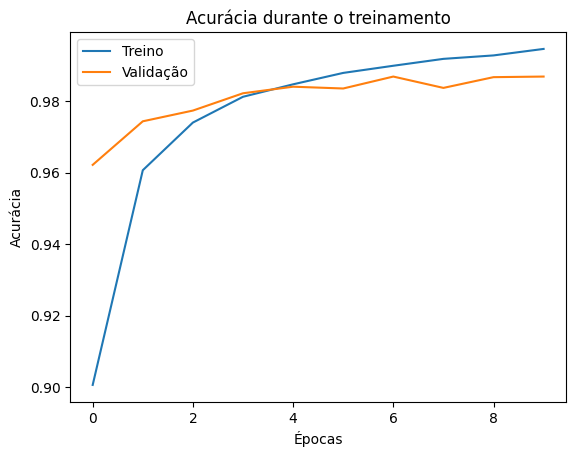

In [10]:
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.title('Acurácia durante o treinamento')
plt.show()

Nesta atividade, foi implementada uma Rede Neural Convolucional baseada na arquitetura LeNet-5 para reconhecimento de dígitos manuscritos utilizando o dataset MNIST. O modelo recebe imagens em escala de cinza com dimensão 28x28 pixels e aplica camadas convolucionais, camadas de pooling e camadas densas para realizar a classificação entre os dígitos de 0 a 9. Após o treinamento, o modelo apresenta alta acurácia no conjunto de teste, demonstrando a eficiência das CNNs em tarefas de visão computacional.